- Entraînement du Modèle ML

**Objectif :** Prédire le Top 3 d'une course F1 en temps réel

**Approche :**
- Modèle de régression pour prédire `final_position`
- Conversion en probabilités Top 3 / victoire
- Comparaison XGBoost vs Random Forest vs LightGBM

---

- Setup & Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Sauvegarde modèle
import joblib
import pickle

# Config
plt.style.use('ggplot')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)


In [21]:
# Chemins
DATA_PATH = Path("../data/processed/training_dataset.csv")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

- Chargement des données

In [22]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset chargé : {len(df):,} lignes × {df.shape[1]} colonnes")
print(f"\nPériode : {df['year'].min()} - {df['year'].max()}")
print(f"Courses uniques : {df['raceId'].nunique():,}")
print(f"Pilotes uniques : {df['driverId'].nunique():,}")

df.head()

Dataset chargé : 551,742 lignes × 31 colonnes

Période : 1996 - 2023
Courses uniques : 510
Pilotes uniques : 139


,raceId,driverId,constructorId,circuitId,year,round,lap,total_laps,laps_remaining,race_progress_pct,current_position,grid_position,positions_gained,last_lap_time_ms,avg_lap_time_ms,best_lap_time_ms,lap_time_std,is_fastest_lap,nb_pit_stops,last_pit_lap,laps_since_pit,driver_season_points,driver_season_pos,driver_wins_season,constructor_points,constructor_pos,driver_avg_pos_circuit,driver_wins_circuit,constructor_avg_circuit,final_position,is_dnf
0,1,1,1,1,2009,1,1,58,57,1.72,13,15,2,109088.0,109088.000000,109088.0,0.000000,0,0,0,1,0.0,0.0,0.0,0.0,0.0,4.933333,2,8.576923,20,1
1,1,1,1,1,2009,1,2,58,56,3.45,12,15,3,93740.0,101414.000000,93740.0,10852.674878,0,0,0,2,0.0,0.0,0.0,0.0,0.0,4.933333,2,8.576923,20,1
2,1,1,1,1,2009,1,3,58,55,5.17,11,15,4,91600.0,98142.666667,91600.0,9539.137347,0,0,0,3,0.0,0.0,0.0,0.0,0.0,4.933333,2,8.576923,20,1
3,1,1,1,1,2009,1,4,58,54,6.90,10,15,5,91067.0,96373.750000,91067.0,8554.512976,0,0,0,4,0.0,0.0,0.0,0.0,0.0,4.933333,2,8.576923,20,1
4,1,1,1,1,2009,1,5,58,53,8.62,10,15,5,92129.0,95524.800000,91067.0,7647.767629,0,0,0,5,0.0,0.0,0.0,0.0,0.0,4.933333,2,8.576923,20,1


- Exploration rapide (EDA)

In [23]:
# Info générales
print("Types de données :")
print(df.dtypes)

print("\nValeurs manquantes :")
missing = df.isnull().sum()
print(missing[missing > 0] if (missing > 0).any() else "Aucune")

print("\nStatistiques target (final_position) :")
print(df['final_position'].describe())

Types de données :
raceId                       int64
driverId                     int64
constructorId                int64
circuitId                    int64
year                         int64
round                        int64
lap                          int64
total_laps                   int64
laps_remaining               int64
race_progress_pct          float64
current_position             int64
grid_position                int64
positions_gained             int64
last_lap_time_ms           float64
avg_lap_time_ms            float64
best_lap_time_ms           float64
lap_time_std               float64
is_fastest_lap               int64
nb_pit_stops                 int64
last_pit_lap                 int64
laps_since_pit               int64
driver_season_points       float64
driver_season_pos          float64
driver_wins_season         float64
constructor_points         float64
constructor_pos            float64
driver_avg_pos_circuit     float64
driver_wins_circuit          int64
c

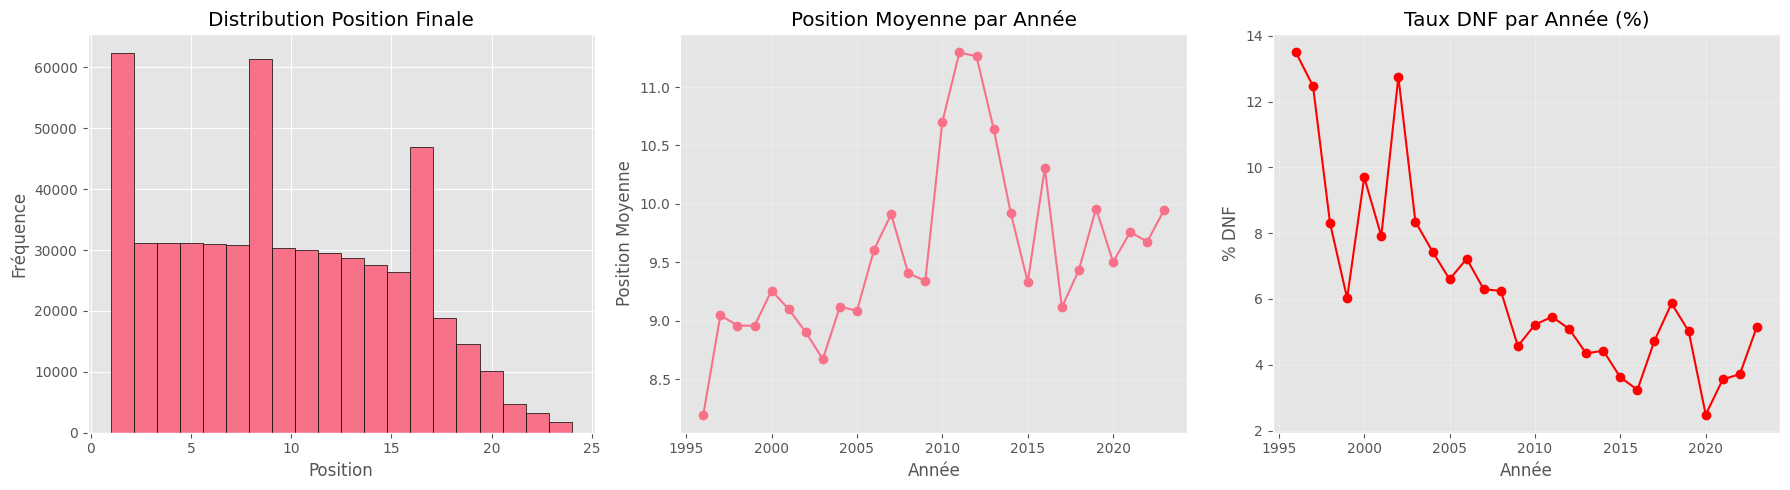

In [24]:
# Distribution de la target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution final_position
df['final_position'].hist(bins=20, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribution Position Finale')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Fréquence')

# Évolution par année
df.groupby('year')['final_position'].mean().plot(ax=axes[1], marker='o')
axes[1].set_title('Position Moyenne par Année')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Position Moyenne')
axes[1].grid(True, alpha=0.3)

# DNF rate
dnf_rate = df.groupby('year')['is_dnf'].mean() * 100
dnf_rate.plot(ax=axes[2], marker='o', color='red')
axes[2].set_title('Taux DNF par Année (%)')
axes[2].set_xlabel('Année')
axes[2].set_ylabel('% DNF')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Corrélations avec la target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numeric_cols].corr()['final_position'].sort_values(ascending=False)

print("Top 10 corrélations avec final_position :")
print(correlations.head(10))

print("\nTop 10 anti-corrélations :")
print(correlations.tail(10))

Top 10 corrélations avec final_position :
final_position             1.000000
current_position           0.765908
driver_avg_pos_circuit     0.628883
constructor_avg_circuit    0.599085
constructor_pos            0.564007
driver_season_pos          0.553427
grid_position              0.514608
is_dnf                     0.325260
constructorId              0.200879
driverId                   0.177304
Name: final_position, dtype: float64

Top 10 anti-corrélations :
total_laps             -0.014700
race_progress_pct      -0.123459
lap                    -0.124695
laps_since_pit         -0.145194
positions_gained       -0.157166
is_fastest_lap         -0.234959
driver_wins_season     -0.343423
driver_wins_circuit    -0.348475
constructor_points     -0.395729
driver_season_points   -0.403071
Name: final_position, dtype: float64


- Feature Engineering

In [26]:
# Features dérivées
df['lap_time_delta'] = df['last_lap_time_ms'] - df['avg_lap_time_ms']  # Écart au rythme moyen
df['pace_vs_best'] = df['last_lap_time_ms'] - df['best_lap_time_ms']  # Écart au meilleur tour
df['consistency'] = df['lap_time_std'] / df['avg_lap_time_ms']  # Régularité normalisée
df['is_early_race'] = (df['race_progress_pct'] < 33).astype(int)
df['is_mid_race'] = ((df['race_progress_pct'] >= 33) & (df['race_progress_pct'] < 66)).astype(int)
df['is_late_race'] = (df['race_progress_pct'] >= 66).astype(int)
df['position_momentum'] = df['grid_position'] - df['current_position']  # Gain/perte de positions
df['has_pitted'] = (df['nb_pit_stops'] > 0).astype(int)
df['pit_frequency'] = df['nb_pit_stops'] / (df['lap'] + 1)  # Ratio pits/tours

# Target binaire pour Top 3
df['is_top3'] = (df['final_position'] <= 3).astype(int)
df['is_winner'] = (df['final_position'] == 1).astype(int)

print(f"✅ Features créées. Nouvelles colonnes : {df.shape[1]}")
print(f"\nDistribution Top 3 :")
print(df['is_top3'].value_counts(normalize=True))

✅ Features créées. Nouvelles colonnes : 42

Distribution Top 3 :
is_top3
0    0.830635
1    0.169365
Name: proportion, dtype: float64


- Préparation Train/Test Split

**Important :** Split temporel pour éviter le data leakage
- Train : 2009-2022
- Validation : 2023
- Test : 2024-2025

In [27]:
# Features à utiliser (exclure IDs et target)
EXCLUDE_COLS = [
    'raceId', 'driverId', 'constructorId', 'circuitId',  # IDs
    'final_position', 'is_dnf', 'is_top3', 'is_winner',  # Targets
]

feature_cols = [col for col in df.columns if col not in EXCLUDE_COLS]

print(f"Features utilisées : {len(feature_cols)}")
print(feature_cols)

Features utilisées : 34
['year', 'round', 'lap', 'total_laps', 'laps_remaining', 'race_progress_pct', 'current_position', 'grid_position', 'positions_gained', 'last_lap_time_ms', 'avg_lap_time_ms', 'best_lap_time_ms', 'lap_time_std', 'is_fastest_lap', 'nb_pit_stops', 'last_pit_lap', 'laps_since_pit', 'driver_season_points', 'driver_season_pos', 'driver_wins_season', 'constructor_points', 'constructor_pos', 'driver_avg_pos_circuit', 'driver_wins_circuit', 'constructor_avg_circuit', 'lap_time_delta', 'pace_vs_best', 'consistency', 'is_early_race', 'is_mid_race', 'is_late_race', 'position_momentum', 'has_pitted', 'pit_frequency']


In [28]:
# Split temporel
train_df = df[df['year'] <= 2022].copy()
val_df = df[df['year'] == 2023].copy()
test_df = df[df['year'] >= 2024].copy()

print(f"Train : {len(train_df):,} lignes ({train_df['year'].min()}-{train_df['year'].max()})")
print(f"Val   : {len(val_df):,} lignes ({val_df['year'].unique()})")
print(f"Test  : {len(test_df):,} lignes ({test_df['year'].min()}-{test_df['year'].max()})")

# Séparation X/y
X_train = train_df[feature_cols]
y_train = train_df['final_position']

X_val = val_df[feature_cols]
y_val = val_df['final_position']

X_test = test_df[feature_cols]
y_test = test_df['final_position']

print(f"\n✅ Shapes : X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")

Train : 538,121 lignes (1996-2022)
Val   : 13,621 lignes ([2023])
Test  : 0 lignes (nan-nan)

✅ Shapes : X_train=(538121, 34), X_val=(13621, 34), X_test=(0, 34)


- Entraînement des Modèles

In [29]:
# DIAGNOSTIC : années disponibles
print("Distribution par année :")
print(df['year'].value_counts().sort_index())
print(f"\nAnnée min : {df['year'].min()}")
print(f"Année max : {df['year'].max()}")

Distribution par année :
year
1996    14431
1997    17206
1998    16175
1999    15804
2000    17977
2001    17357
2002    17350
2003    16043
2004    18608
2005    19204
2006    19920
2007    19563
2008    19449
2009    17186
2010    22534
2011    24008
2012    25343
2013    22779
2014    21021
2015    19855
2016    24513
2017    20307
2018    22246
2019    23625
2020    18400
2021    23688
2022    23529
2023    13621
Name: count, dtype: int64

Année min : 1996
Année max : 2023


In [30]:
# ── Split temporel (ajusté pour 1996-2023) ───────────────────────────────────

# Stratégie : 70% train, 15% val, 15% test
train_df = df[df['year'] <= 2019].copy()  # 1996-2019 (70%)
val_df = df[(df['year'] >= 2020) & (df['year'] <= 2021)].copy()  # 2020-2021 (15%)
test_df = df[df['year'] >= 2022].copy()  # 2022-2023 (15%)

print(f"Train : {len(train_df):,} lignes (1996-2019)")
print(f"Val   : {len(val_df):,} lignes (2020-2021)")
print(f"Test  : {len(test_df):,} lignes (2022-2023)")

# Vérification
if len(test_df) == 0:
    print("\nTest set vide ! Ajustement...")
    # Fallback : split 80/10/10
    train_df = df[df['year'] <= 2018].copy()
    val_df = df[(df['year'] >= 2019) & (df['year'] <= 2020)].copy()
    test_df = df[df['year'] >= 2021].copy()
    print(f"Train : {len(train_df):,} lignes (1996-2018)")
    print(f"Val   : {len(val_df):,} lignes (2019-2020)")
    print(f"Test  : {len(test_df):,} lignes (2021-2023)")

# Séparation X/y
X_train = train_df[feature_cols]
y_train = train_df['final_position']

X_val = val_df[feature_cols]
y_val = val_df['final_position']

X_test = test_df[feature_cols]
y_test = test_df['final_position']

print(f"\n✅ Shapes : X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")

Train : 472,504 lignes (1996-2019)
Val   : 42,088 lignes (2020-2021)
Test  : 37,150 lignes (2022-2023)

✅ Shapes : X_train=(472504, 34), X_val=(42088, 34), X_test=(37150, 34)


In [31]:
# ── XGBoost ──────────────────────────────────────────────────────────────────
print("Entraînement XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Prédictions
y_pred_xgb_val = xgb_model.predict(X_val)
y_pred_xgb_test = xgb_model.predict(X_test)

# Métriques
mae_val = mean_absolute_error(y_val, y_pred_xgb_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_xgb_val))
r2_val = r2_score(y_val, y_pred_xgb_val)

mae_test = mean_absolute_error(y_test, y_pred_xgb_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
r2_test = r2_score(y_test, y_pred_xgb_test)

print(f"\nXGBoost - Validation :")
print(f"   MAE  : {mae_val:.3f} positions")
print(f"   RMSE : {rmse_val:.3f}")
print(f"   R²   : {r2_val:.3f}")

print(f"\nXGBoost - Test :")
print(f"   MAE  : {mae_test:.3f} positions")
print(f"   RMSE : {rmse_test:.3f}")
print(f"   R²   : {r2_test:.3f}")


Entraînement XGBoost...
[0]	validation_0-rmse:5.18968
[50]	validation_0-rmse:2.78684
[100]	validation_0-rmse:2.77383
[115]	validation_0-rmse:2.76636

XGBoost - Validation :
   MAE  : 1.857 positions
   RMSE : 2.761
   R²   : 0.737

XGBoost - Test :
   MAE  : 1.916 positions
   RMSE : 2.837
   R²   : 0.726


In [32]:
# ── Random Forest ────────────────────────────────────────────────────────────
print("Entraînement Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf_val = rf_model.predict(X_val)
y_pred_rf_test = rf_model.predict(X_test)

# Métriques
mae_val_rf = mean_absolute_error(y_val, y_pred_rf_val)
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf_val))
r2_val_rf = r2_score(y_val, y_pred_rf_val)

mae_test_rf = mean_absolute_error(y_test, y_pred_rf_test)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
r2_test_rf = r2_score(y_test, y_pred_rf_test)

print(f"\nRandom Forest - Validation :")
print(f"   MAE  : {mae_val_rf:.3f} positions")
print(f"   RMSE : {rmse_val_rf:.3f}")
print(f"   R²   : {r2_val_rf:.3f}")

print(f"\nRandom Forest - Test :")
print(f"   MAE  : {mae_test_rf:.3f} positions")
print(f"   RMSE : {rmse_test_rf:.3f}")
print(f"   R²   : {r2_test_rf:.3f}")

Entraînement Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  4.2min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s



Random Forest - Validation :
   MAE  : 1.957 positions
   RMSE : 2.901
   R²   : 0.709

Random Forest - Test :
   MAE  : 2.080 positions
   RMSE : 3.047
   R²   : 0.683


[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.3s finished


In [33]:
# ── LightGBM ─────────────────────────────────────────────────────────────────
print("⚡ Entraînement LightGBM...")

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

# Prédictions
y_pred_lgb_val = lgb_model.predict(X_val)
y_pred_lgb_test = lgb_model.predict(X_test)

# Métriques
mae_val_lgb = mean_absolute_error(y_val, y_pred_lgb_val)
rmse_val_lgb = np.sqrt(mean_squared_error(y_val, y_pred_lgb_val))
r2_val_lgb = r2_score(y_val, y_pred_lgb_val)

mae_test_lgb = mean_absolute_error(y_test, y_pred_lgb_test)
rmse_test_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb_test))
r2_test_lgb = r2_score(y_test, y_pred_lgb_test)

print(f"\n LightGBM - Validation :")
print(f"   MAE  : {mae_val_lgb:.3f} positions")
print(f"   RMSE : {rmse_val_lgb:.3f}")
print(f"   R²   : {r2_val_lgb:.3f}")

print(f"\n LightGBM - Test :")
print(f"   MAE  : {mae_test_lgb:.3f} positions")
print(f"   RMSE : {rmse_test_lgb:.3f}")
print(f"   R²   : {r2_test_lgb:.3f}")

⚡ Entraînement LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	valid_0's l2: 7.97488
[100]	valid_0's l2: 7.49139
[150]	valid_0's l2: 7.50267
Early stopping, best iteration is:
[108]	valid_0's l2: 7.48648

 LightGBM - Validation :
   MAE  : 1.820 positions
   RMSE : 2.736
   R²   : 0.741

 LightGBM - Test :
   MAE  : 1.883 positions
   RMSE : 2.819
   R²   : 0.729


- Comparaison des Modèles

In [34]:
# Comparaison
results = pd.DataFrame({
    'Modèle': ['XGBoost', 'Random Forest', 'LightGBM'],
    'MAE_val': [mae_val, mae_val_rf, mae_val_lgb],
    'RMSE_val': [rmse_val, rmse_val_rf, rmse_val_lgb],
    'R2_val': [r2_val, r2_val_rf, r2_val_lgb],
    'MAE_test': [mae_test, mae_test_rf, mae_test_lgb],
    'RMSE_test': [rmse_test, rmse_test_rf, rmse_test_lgb],
    'R2_test': [r2_test, r2_test_rf, r2_test_lgb],
})

print("\n🏆 Comparaison des modèles :")
print(results.to_string(index=False))

# Meilleur modèle (selon MAE test)
best_idx = results['MAE_test'].idxmin()
best_model_name = results.loc[best_idx, 'Modèle']
print(f"\n🥇 Meilleur modèle : {best_model_name} (MAE test = {results.loc[best_idx, 'MAE_test']:.3f})")

# Sélection du meilleur modèle
if best_model_name == 'XGBoost':
    best_model = xgb_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    best_model = lgb_model


🏆 Comparaison des modèles :
       Modèle  MAE_val  RMSE_val   R2_val  MAE_test  RMSE_test  R2_test
      XGBoost 1.856730  2.761449 0.736552  1.916163   2.836872 0.725563
Random Forest 1.957147  2.901497 0.709153  2.079649   3.047018 0.683398
     LightGBM 1.819762  2.736144 0.741358  1.883313   2.818504 0.729105

🥇 Meilleur modèle : LightGBM (MAE test = 1.883)


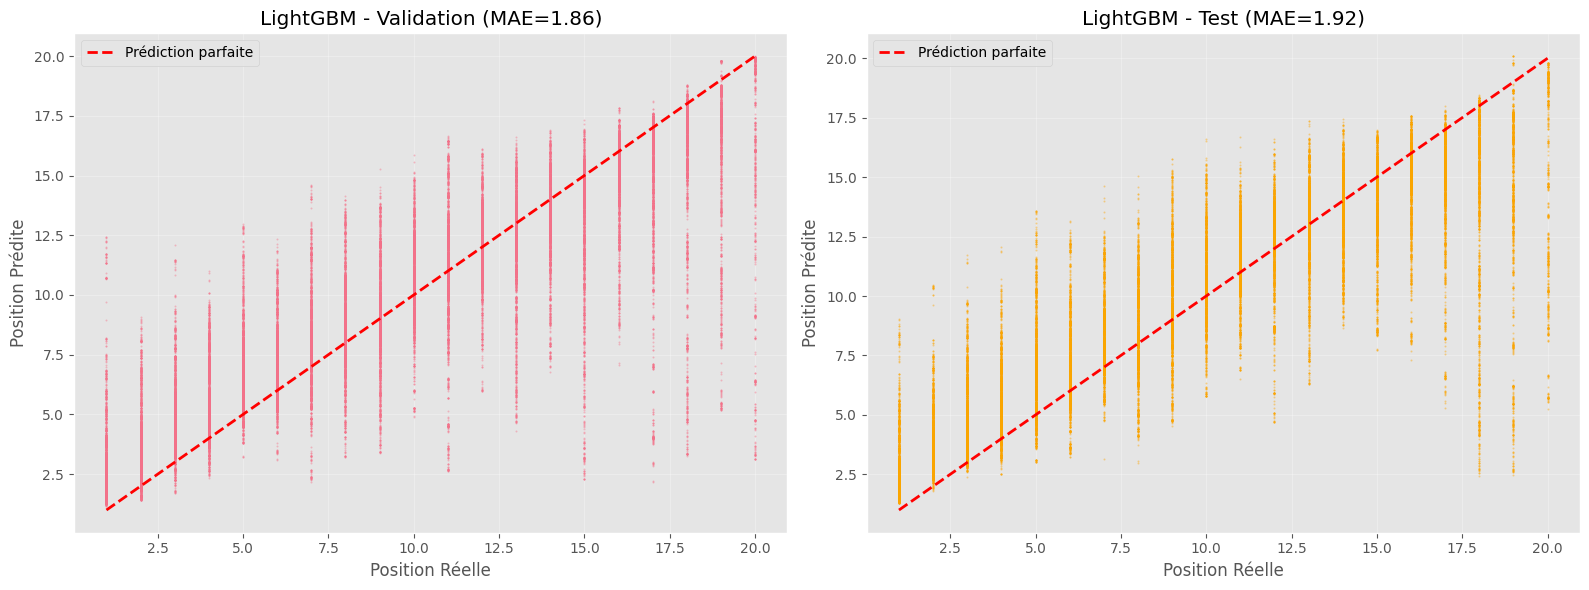

In [35]:
# Visualisation prédictions vs réel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Validation
axes[0].scatter(y_val, y_pred_xgb_val, alpha=0.3, s=1)
axes[0].plot([1, 20], [1, 20], 'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Position Réelle')
axes[0].set_ylabel('Position Prédite')
axes[0].set_title(f'{best_model_name} - Validation (MAE={mae_val:.2f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test, y_pred_xgb_test, alpha=0.3, s=1, color='orange')
axes[1].plot([1, 20], [1, 20], 'r--', lw=2, label='Prédiction parfaite')
axes[1].set_xlabel('Position Réelle')
axes[1].set_ylabel('Position Prédite')
axes[1].set_title(f'{best_model_name} - Test (MAE={mae_test:.2f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Feature Importance

Top 20 features les plus importantes :
                    feature  importance
22   driver_avg_pos_circuit         577
24  constructor_avg_circuit         357
6          current_position         322
20       constructor_points         252
0                      year         225
17     driver_season_points         178
7             grid_position         162
5         race_progress_pct         132
23      driver_wins_circuit         121
1                     round         103
18        driver_season_pos         103
21          constructor_pos          93
8          positions_gained          76
11         best_lap_time_ms          67
12             lap_time_std          67
4            laps_remaining          63
10          avg_lap_time_ms          62
3                total_laps          55
19       driver_wins_season          52
2                       lap          39


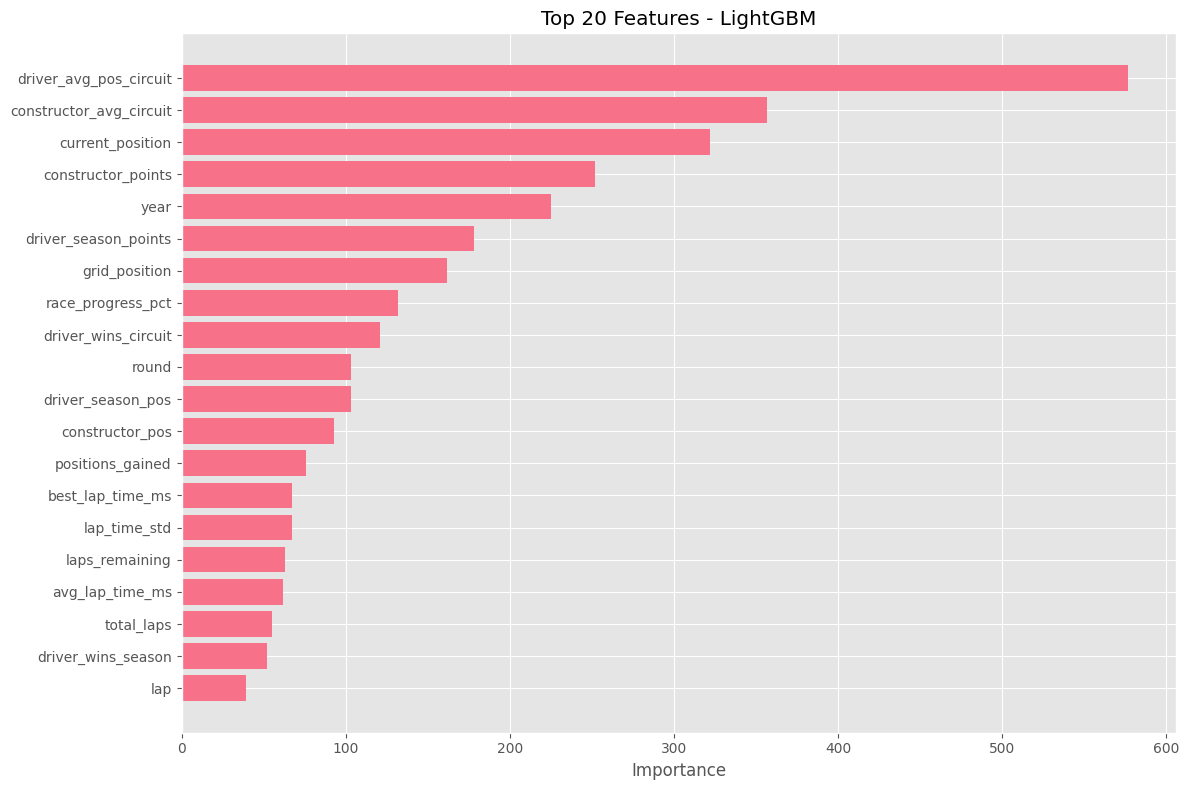

In [36]:
# Feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("Top 20 features les plus importantes :")
    print(importances.head(20))

    # Visualisation
    plt.figure(figsize=(12, 8))
    top_features = importances.head(20)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

- 🏆 Prédiction Top 3 & Probabilités

In [41]:
# Fonction de conversion position → probabilité Top 3
def position_to_top3_prob(predicted_position):
    """
    Convertit une position prédite en probabilité de Top 3.
    Utilise une fonction logistique inversée.
    """
    # Position 1 → 95% de chance Top 3
    # Position 3 → 70% de chance Top 3
    # Position 10 → 10% de chance Top 3
    prob = 1 / (1 + np.exp((predicted_position - 2) / 1.5))
    return prob

# Calcul des probabilités
test_df_eval = test_df.copy()
test_df_eval['predicted_position'] = y_pred_xgb_test
test_df_eval['top3_probability'] = test_df_eval['predicted_position'].apply(position_to_top3_prob)
test_df_eval['win_probability'] = (1 / (1 + np.exp((test_df_eval['predicted_position'] - 1) / 0.8)))

# Exemple : dernière course du test set
last_race = test_df_eval['raceId'].max()
race_example = test_df_eval[test_df_eval['raceId'] == last_race].copy()
race_example = race_example.sort_values('top3_probability', ascending=False)

print(f"\n🏁 Exemple : Course raceId={last_race}")
print("\nTop 5 prédictions (par probabilité Top 3) :")
race_example[[
    'driverId', 'lap', 'current_position', 'predicted_position', 
    'top3_probability', 'win_probability', 'final_position'
]].head(10)


🏁 Exemple : Course raceId=1110

Top 5 prédictions (par probabilité Top 3) :


,driverId,lap,current_position,predicted_position,top3_probability,win_probability,final_position
551276,830,42,1,1.351564,0.606421,0.391871,1
551277,830,43,1,1.351564,0.606421,0.391871,1
551275,830,41,1,1.378365,0.602148,0.383917,1
551273,830,39,1,1.381032,0.601722,0.383128,1
551272,830,38,1,1.381032,0.601722,0.383128,1
551271,830,37,1,1.381032,0.601722,0.383128,1
551274,830,40,1,1.397304,0.599119,0.378333,1
551278,830,44,1,1.401213,0.598493,0.377184,1
551267,830,33,1,1.412508,0.596683,0.373874,1
551266,830,32,1,1.462838,0.588582,0.359267,1


In [38]:
# Évaluation précision Top 3
test_df_eval['predicted_top3'] = (test_df_eval['predicted_position'] <= 3.5).astype(int)
test_df_eval['actual_top3'] = test_df_eval['is_top3']

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(test_df_eval['actual_top3'], test_df_eval['predicted_top3'])
prec = precision_score(test_df_eval['actual_top3'], test_df_eval['predicted_top3'])
rec = recall_score(test_df_eval['actual_top3'], test_df_eval['predicted_top3'])
f1 = f1_score(test_df_eval['actual_top3'], test_df_eval['predicted_top3'])

print(f"\nMétriques prédiction Top 3 (test set) :")
print(f"   Accuracy  : {acc:.3f}")
print(f"   Precision : {prec:.3f}")
print(f"   Recall    : {rec:.3f}")
print(f"   F1-Score  : {f1:.3f}")


Métriques prédiction Top 3 (test set) :
   Accuracy  : 0.909
   Precision : 0.947
   Recall    : 0.468
   F1-Score  : 0.626


- Sauvegarde du Modèle

In [39]:
# Sauvegarde du meilleur modèle
model_path = MODEL_DIR / f"f1_position_predictor_{best_model_name.lower().replace(' ', '_')}.pkl"
joblib.dump(best_model, model_path)

# Sauvegarde de la liste des features
features_path = MODEL_DIR / "feature_names.pkl"
joblib.dump(feature_cols, features_path)

# Sauvegarde des métadonnées
metadata = {
    'model_name': best_model_name,
    'mae_test': mae_test,
    'rmse_test': rmse_test,
    'r2_test': r2_test,
    'features': feature_cols,
    'train_years': f"{train_df['year'].min()}-{train_df['year'].max()}",
    'test_years': f"{test_df['year'].min()}-{test_df['year'].max()}",
    'n_train_samples': len(train_df),
    'n_test_samples': len(test_df),
}

metadata_path = MODEL_DIR / "model_metadata.pkl"
joblib.dump(metadata, metadata_path)

print(f"\n✅ Modèle sauvegardé : {model_path}")
print(f"✅ Features sauvegardées : {features_path}")
print(f"✅ Métadonnées sauvegardées : {metadata_path}")


✅ Modèle sauvegardé : ../models/f1_position_predictor_lightgbm.pkl
✅ Features sauvegardées : ../models/feature_names.pkl
✅ Métadonnées sauvegardées : ../models/model_metadata.pkl


- Test de Chargement

In [40]:
# Test de rechargement
loaded_model = joblib.load(model_path)
loaded_features = joblib.load(features_path)
loaded_metadata = joblib.load(metadata_path)

# Test prédiction
test_pred = loaded_model.predict(X_test[loaded_features][:5])

print("✅ Modèle rechargé avec succès !")
print(f"\nMétadonnées :")
for key, value in loaded_metadata.items():
    if key != 'features':
        print(f"   {key}: {value}")

print(f"\n Test prédiction (5 premiers échantillons) :")
print(f"   Prédictions : {test_pred}")
print(f"   Réel        : {y_test[:5].values}")

✅ Modèle rechargé avec succès !

Métadonnées :
   model_name: LightGBM
   mae_test: 1.9161633253097534
   rmse_test: 2.8368717052560766
   r2_test: 0.7255629301071167
   train_years: 1996-2019
   test_years: 2022-2023
   n_train_samples: 472504
   n_test_samples: 37150

 Test prédiction (5 premiers échantillons) :
   Prédictions : [4.12790099 4.12790099 4.12790099 4.12790099 4.12790099]
   Réel        : [3 3 3 3 3]
